In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

## SMA check

In [2]:
sma_vessel_path = "../test_data/LabelTr/PanTS_00000086/segmentations/superior_mesenteric_artery.nii.gz"

sma_centreline_path = "../outputs/centrelines/PanTS_00000086/superior_mesenteric_artery_centerline.nii.gz"

sma_vessel = nib.load(sma_vessel_path).get_fdata()
centreline = nib.load(sma_centreline_path).get_fdata()

print("Vessel shape:", sma_vessel.shape)
print("Centreline shape:", centreline.shape)

Vessel shape: (455, 371, 75)
Centreline shape: (455, 371, 75)


In [3]:
vessel_mask = sma_vessel > 0
centreline_mask = centreline > 0

print("Vessel voxels:", vessel_mask.sum())
print("Centreline voxels:", centreline_mask.sum())

Vessel voxels: 2355
Centreline voxels: 59


In [4]:
z_indices = np.where(vessel_mask.any(axis=(1,2)))[0]

print(z_indices.min(), z_indices.max())

184 228


In [5]:
z = z_indices[len(z_indices)//2]

print("Viewing slice:", z)

Viewing slice: 206


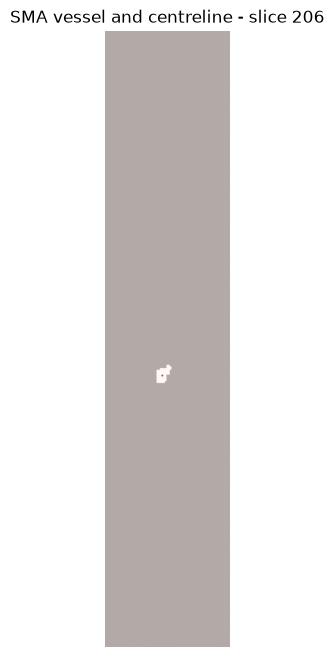

In [6]:
plt.figure(figsize=(8,8))

plt.imshow(vessel_mask[z], cmap="gray")

plt.imshow(
    centreline_mask[z],
    cmap="Reds",
    alpha=0.7
)

plt.title(f"SMA vessel and centreline - slice {z}")
plt.axis("off")
plt.show()

In [7]:
coords = np.argwhere(centreline_mask)

print("Centreline min:", coords.min(axis=0))
print("Centreline max:", coords.max(axis=0))

Centreline min: [189 175  19]
Centreline max: [222 216  51]


In [8]:
centreline_slices = np.where(centreline_mask.any(axis=(1,2)))[0]

print("Number of slices:", len(centreline_slices))
print(centreline_slices)

Number of slices: 34
[189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206
 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222]


In [9]:
centreline_area = centreline_mask.sum(axis=(1,2))

z = np.argmax(centreline_area)

print("Best slice:", z)
print("Centreline pixels:", centreline_area[z])

Best slice: 217
Centreline pixels: 6


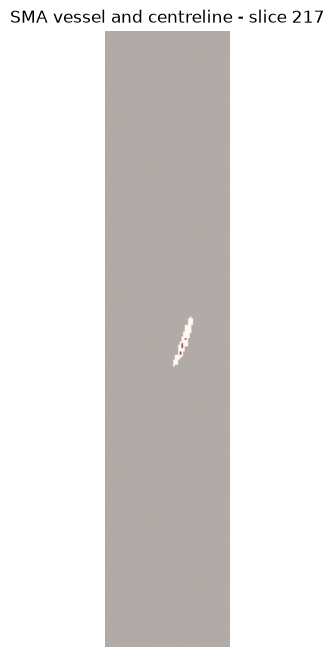

In [10]:
plt.figure(figsize=(8,8))

plt.imshow(vessel_mask[z], cmap="gray")

plt.imshow(
    centreline_mask[z],
    cmap="Reds",
    alpha=0.7
)

plt.title(f"SMA vessel and centreline - slice {z}")
plt.axis("off")
plt.show()

In [11]:
vessel_coords = np.argwhere(vessel_mask)

print("Vessel min:", vessel_coords.min(axis=0))
print("Vessel max:", vessel_coords.max(axis=0))

centre_coords = np.argwhere(centreline_mask)

print("Centreline min:", centre_coords.min(axis=0))
print("Centreline max:", centre_coords.max(axis=0))

Vessel min: [184 172  15]
Vessel max: [228 219  52]
Centreline min: [189 175  19]
Centreline max: [222 216  51]
